# Temporal Stability and Risk Trajectory Analysis

This notebook analyzes how the predicted sepsis risk changes over time for each patient.
Instead of making a single prediction, we monitor the patient's risk trajectory over ICU hours.

We calculate:
- Risk score over time
- Volatility of risk
- Stability index
- Sudden jumps in risk
- Risk trend (Increasing / Decreasing / Stable)
- Risk category (Low / Medium / High)

**Importing required libraries**

In [15]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

**Load Model and dataset**

In [14]:
df = pd.read_csv("../data/sepsis_final.csv")

stack_model = joblib.load("../models/stacking_model.pkl")

features = df.drop(["SepsisLabel", "patient_id"], axis=1).columns

**Patient Risk Analysis**

This function analyzes sepsis risk for a single patient over time
using the stacking model predictions.

In [16]:
def analyze_patient(patient_id):
    
    patient_data = df[df["patient_id"] == patient_id]
    patient_data = patient_data.sort_values("ICULOS")
    
    X_patient = patient_data[features]
    
    # Stacking model probability
    risk_score = stack_model.predict_proba(X_patient)[:, 1]
    
    # Smooth risk curve
    risk_score = pd.Series(risk_score).rolling(3, min_periods=1).mean().values
    
    # Volatility
    volatility = float(np.std(risk_score))
    stability_index = float(1 / (1 + volatility))
    
    # Sudden jumps
    risk_diff = np.diff(risk_score)
    sudden_jumps = int(np.sum(risk_diff > 0.15))
    
    # Trend (slope)
    trend = np.polyfit(patient_data["ICULOS"], risk_score, 1)[0]
    
    if trend > 0:
        risk_trend = "Increasing"
    elif trend < 0:
        risk_trend = "Decreasing"
    else:
        risk_trend = "Stable"
    
    # Current risk
    current_risk = float(risk_score[-1])
    
    if current_risk > 0.7:
        risk_category = "High"
    elif current_risk > 0.4:
        risk_category = "Medium"
    else:
        risk_category = "Low"
    
    return {
        "current_risk": current_risk,
        "risk_category": risk_category,
        "volatility": volatility,
        "stability_index": stability_index,
        "sudden_jumps": sudden_jumps,
        "risk_trend": risk_trend,
        "risk_scores": risk_score,
        "iculos": patient_data["ICULOS"].values
    }

## Test one Patient

We test the temporal risk analysis on a sample patient.

In [17]:
result = analyze_patient("A_000005")

print("Current Risk:", result["current_risk"])
print("Risk Category:", result["risk_category"])
print("Volatility:", result["volatility"])
print("Stability Index:", result["stability_index"])
print("Sudden Jumps:", result["sudden_jumps"])
print("Risk Trend:", result["risk_trend"])

Current Risk: 1.1367895123253861e-05
Risk Category: Low
Volatility: 0.055403595992471855
Stability Index: 0.9475048254498585
Sudden Jumps: 0
Risk Trend: Decreasing


## Risk Trend Visualization

**We plot the sepsis risk score over ICU hours to visualize the risk trajectory.**

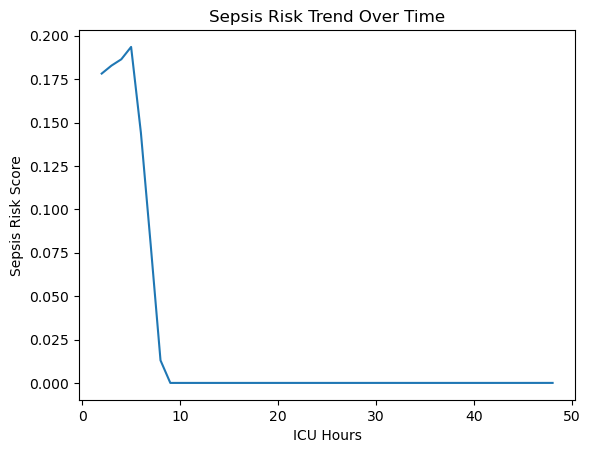

In [18]:
plt.figure()
plt.plot(result["iculos"], result["risk_scores"])
plt.xlabel("ICU Hours")
plt.ylabel("Sepsis Risk Score")
plt.title("Sepsis Risk Trend Over Time")
plt.show()

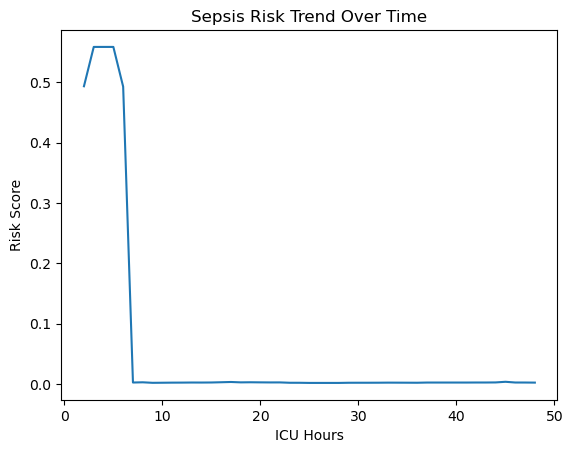

In [35]:
import matplotlib.pyplot as plt

plt.plot(result["iculos"], result["risk_scores"])
plt.xlabel("ICU Hours")
plt.ylabel("Risk Score")
plt.title("Sepsis Risk Trend Over Time")
plt.show()